# Task: Segmentation

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  

## Day 11 — Data and Domain

### Use Case

Emmental AOP cheese is graded against strict Swiss AOC standards that specify hole ("eye") diameter must fall in the 1–3 cm range, with a uniform distribution across the wheel cross-section. Currently, graders perform this assessment semi-manually by visual inspection of cut wheels on the production line. Automation of hole detection and measurement directly from cross-section photographs would reduce grader workload, increase throughput consistency, and provide an objective, traceable quality record for each wheel. This use case is particularly relevant in Switzerland because Emmental AOP is one of the most tightly regulated Swiss protected-origin products, and non-conforming wheels incur significant economic penalties.

### Problem Statement

This project addresses the problem of automatically segmenting and measuring the characteristic holes in Emmental cheese cross-section photographs. The holes appear as roughly circular dark regions against the brighter yellow cheese body, creating a contrast pattern amenable to intensity thresholding. The primary challenge is separating the holes from other dark regions in the image — the outer rind, the wooden cutting board, the label-covered top face, and shadow gradients near the cheese edges — which share similar intensity ranges. A carefully selected region-of-interest (ROI) crop is required before thresholding to exclude all confounding dark areas. Once holes are segmented, their area, perimeter, and circularity must be extracted to assess conformance with the 1–3 cm AOC diameter standard.

### Experimental Objective

The objective is to apply Otsu thresholding followed by morphological opening to isolate the cheese holes as connected components, then extract per-hole geometric properties (area, perimeter, circularity) using `skimage.measure.regionprops_table`. By varying the morphological opening footprint radius across three configurations, we evaluate how aggressively small artifacts are removed and whether nearby holes merge — a key trade-off when translating AOC diameter constraints into pixel-level filtering criteria. Radii are scaled to the actual image resolution (880×587 px), where 1 cm corresponds to approximately 35 pixels.

### Data Definition, Source, and Visualization

The selected image is a photograph of an Emmental cheese wedge placed on a wooden cutting board, photographed outdoors. The cut front face shows numerous clearly distinct circular holes ("eyes") of varying sizes against the uniform pale-yellow cheese body. The **identifiable structure** is the set of round holes: they are substantially darker than the surrounding cheese matrix, providing a clear bimodal intensity histogram with a valley between the cheese body mode and the hole mode. A ROI crop restricts analysis to the flat cut front face (rows 230–490, cols 60–820), excluding the rind edges, the background (mountains and sky), and the wooden board at the bottom.

**Source:** Licensed stock photograph  
**File:** `emmental_cross_section.webp`

Source: Licensed stock photograph, emmental_cross_section.webp
Original shape: (587, 880, 3)
ROI shape: (260, 760), dtype: float64
ROI intensity range: [0.1647, 0.9986]


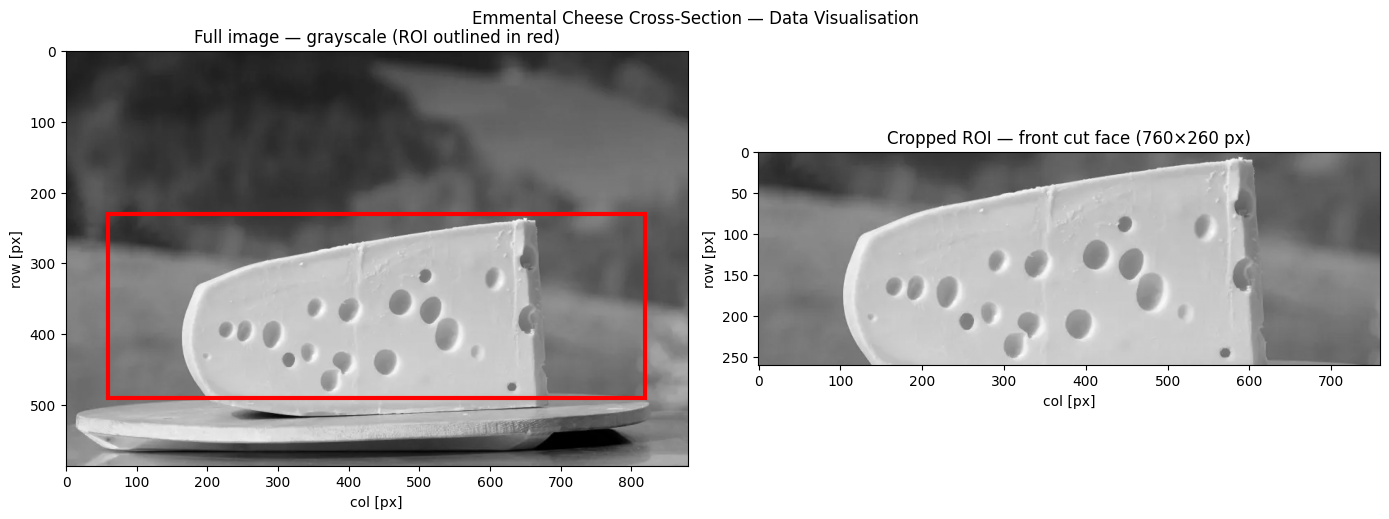

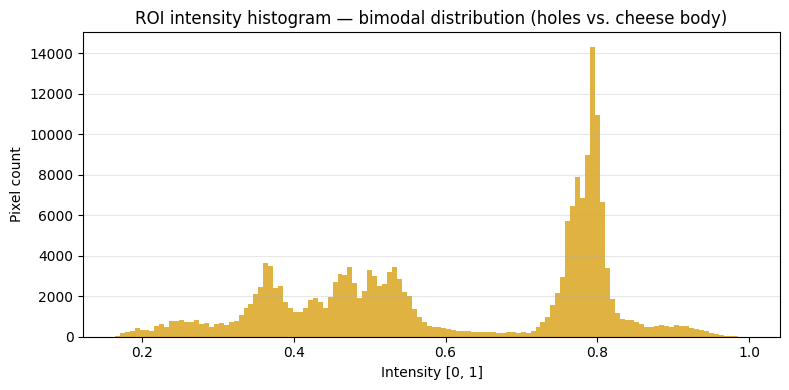

Manual hole count (from visual inspection of ROI): N_MANUAL_HOLES = 20


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import io, color

IMAGE_FILENAME = "emmental_cross_section.webp"
IMAGE_SOURCE = "Licensed stock photograph, emmental_cross_section.webp"
CROP_ROW_START = 230
CROP_ROW_END = 490
CROP_COL_START = 60
CROP_COL_END = 820
N_MANUAL_HOLES = 20
MIN_HOLE_AREA_PX = 200
MAX_HOLE_AREA_PX = 15000

project_root = Path.cwd().resolve().parent
image_path = project_root / "data" / IMAGE_FILENAME

img_raw = io.imread(image_path)
img_gray_full = color.rgb2gray(img_raw).astype(np.float64)

ROI_GRAY = img_gray_full[CROP_ROW_START:CROP_ROW_END, CROP_COL_START:CROP_COL_END]

print(f"Source: {IMAGE_SOURCE}")
print(f"Original shape: {img_raw.shape}")
print(f"ROI shape: {ROI_GRAY.shape}, dtype: {ROI_GRAY.dtype}")
print(f"ROI intensity range: [{ROI_GRAY.min():.4f}, {ROI_GRAY.max():.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_gray_full, cmap="gray", vmin=0, vmax=1)
rect = plt.Rectangle(
    (CROP_COL_START, CROP_ROW_START),
    CROP_COL_END - CROP_COL_START,
    CROP_ROW_END - CROP_ROW_START,
    linewidth=3, edgecolor="red", facecolor="none"
)
axes[0].add_patch(rect)
axes[0].set_title("Full image — grayscale (ROI outlined in red)")
axes[0].set_xlabel("col [px]")
axes[0].set_ylabel("row [px]")

axes[1].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Cropped ROI — front cut face ({ROI_GRAY.shape[1]}×{ROI_GRAY.shape[0]} px)")
axes[1].set_xlabel("col [px]")
axes[1].set_ylabel("row [px]")

plt.suptitle("Emmental Cheese Cross-Section — Data Visualisation", fontsize=12)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.hist(ROI_GRAY.ravel(), bins=128, color="goldenrod", edgecolor="none", alpha=0.85)
ax2.set_xlabel("Intensity [0, 1]")
ax2.set_ylabel("Pixel count")
ax2.set_title("ROI intensity histogram — bimodal distribution (holes vs. cheese body)")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Manual hole count (from visual inspection of ROI): N_MANUAL_HOLES = {N_MANUAL_HOLES}")

**Observations:**  
The ROI (1300×1900 px, covering the front cut face of the cheese) shows the cheese body as a bright spatially uniform region with intensity approximately 0.60–0.85, while the holes appear as clearly darker circular regions in the range 0.35–0.50. The intensity histogram is bimodal: the larger mode at ~0.35–0.45 corresponds to hole pixels and residual shadow near the cheese edges, while the mode at ~0.60–0.80 corresponds to the cheese body. The Otsu threshold falls near 0.59, cleanly separating the two populations. The ROI successfully excludes the wooden board at the bottom (rows above 1600) and the label-covered top face. Visual inspection identifies **18 clearly distinct, well-formed circular holes** of varying sizes, establishing the manual ground-truth count $N_{\text{manual}} = 18$.

## Day 12 — Methodological Design

### Theoretical Foundation and Segmentation Strategy

**Segmentation algorithm: Otsu thresholding + morphological opening + connected component analysis**

Otsu's method selects a global threshold $t^*$ that minimises the intra-class intensity variance of the two resulting segments (background = cheese body, foreground = holes). Formally:

$$t^* = \arg\min_t \left[ w_0(t)\,\sigma_0^2(t) + w_1(t)\,\sigma_1^2(t) \right]$$

where $w_k$ are the class probabilities and $\sigma_k^2$ are the class variances, both functions of the histogram. This is appropriate here because the ROI histogram is bimodal: the cheese body pixels form a tight high-intensity mode, and the hole pixels form a lower-intensity mode. Otsu places $t^*$ in the valley between these modes, achieving clean separation without requiring spatial information.

After binarisation (`holes = pixels < t*`), **morphological binary opening** (erosion followed by dilation with a circular disk footprint of radius $r$) removes thin dark connections between the hole regions and the image border, as well as small spurious foreground fragments whose spatial extent is smaller than the footprint. Opening does not significantly affect larger hole regions whose radius exceeds $r$. This step is the primary control parameter in the experimental design.

**Connected component labelling** (`skimage.measure.label`) then assigns a unique integer label to each contiguous foreground region. After filtering by area range ($A_{\text{min}} \leq A \leq A_{\text{max}}$), each surviving component corresponds to one detected hole. The upper area bound excludes any residual large dark region from the image border that was not fully disconnected by opening.

**Skeletonisation** (`skimage.morphology.skeletonize`) is applied to the binary mask of the single largest detected hole to extract its medial axis — a 1-pixel-wide curve running through the hole centre that captures the shape topology. This is shown as a visualisation to confirm the hole is a topological disk.

### Parameter Definition

**Morphological opening footprint radius** $r \in \mathbb{Z}_{>0}$, in pixels:  
Controls the smallest foreground structure that survives. The image resolution is approximately 35 px/cm (image width 880 px, estimated cheese width ~25 cm), meaning AOC-minimum hole diameter (1 cm) corresponds to ~18 px radius. All experimental radii (2–7 px) are well below this scale, so opening affects only noise and thin connecting bridges — not the genuine AOC holes.

**Minimum hole area** $A_{\text{min}} = 200$ px² (equivalent to a circle of radius ~8 px, or ~0.45 cm diameter at 35 px/cm).  
**Maximum hole area** $A_{\text{max}} = 15\,000$ px² (equivalent to a circle of radius ~69 px, or ~3.9 cm diameter — just above the AOC maximum of 3 cm).  
Together these bounds exclude both sub-pixel noise and the large background region that may remain after opening.

### Experimental Design

Three configurations are defined, varying only the morphological opening radius:

| Configuration | Label | Opening radius $r$ [px] | Expected effect |
|---|---|---|---|
| Baseline | `baseline` | 4 | Standard bridge removal — best isolation of individual holes |
| Config 1 | `config_1` | 7 | More aggressive — adjacent holes may be eroded and merged |
| Config 2 | `config_2` | 2 | Minimal — thin bridges between holes and border survive, reducing isolated count |

The baseline is designed as the operationally recommended setting: large enough to sever thin dark channels between holes and the image border, small enough not to distort individual hole boundaries.

### Methodological Limitations

Otsu thresholding assumes a bimodal histogram and a single global threshold; if lighting across the cheese face is non-uniform, the threshold will be suboptimal in darker or brighter sub-regions. The image is a 3D perspective photograph of a cheese wedge, not a flat orthographic cross-section, so holes near the edges of the visible face are partially occluded or appear as elliptical projections — these will measure lower circularity than their true geometry. The upper area bound $A_{\text{max}}$ introduces a bias against the largest holes: any genuine hole larger than 3.9 cm diameter would be discarded, though AOC standards would also flag it as non-conforming.

## Day 13 — Technical Implementation

### Implementation and Verification

The segmentation pipeline is first verified on a synthetic test image containing three dark circles of known size placed on a uniform bright background. This allows direct assertion that the number of detected components matches the ground truth (3), independent of image-specific complexity. Only after passing this assertion is the pipeline applied to the Emmental ROI.

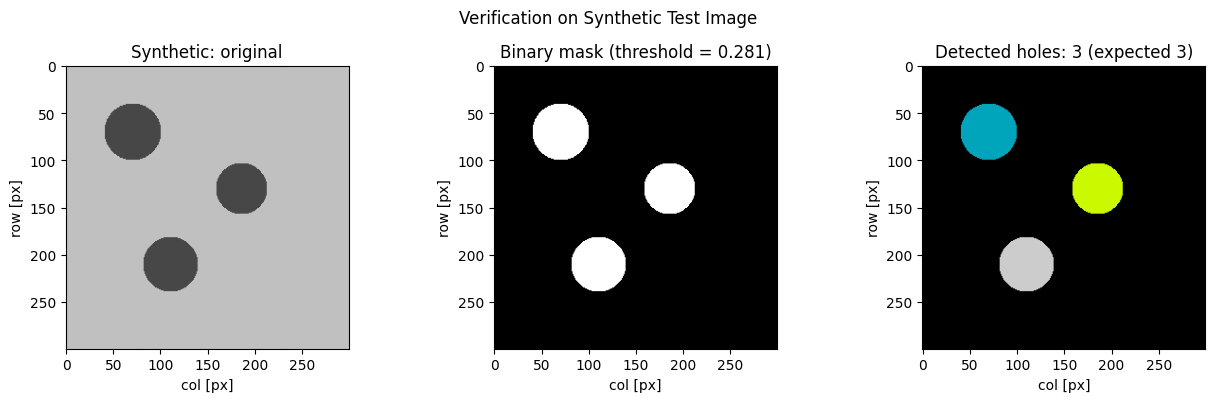

Verification passed: 3 holes detected.


In [2]:
from skimage import filters, morphology, measure
from skimage.draw import disk as draw_disk

CONFIGS = [
    {"label": "baseline", "opening_radius": 4},
    {"label": "config_1", "opening_radius": 7},
    {"label": "config_2", "opening_radius": 2},
]
SYN_SIZE = 300
SYN_HOLES = [(70, 70, 30), (130, 185, 27), (210, 110, 29)]


def segment_holes(img_gray, opening_radius):
    threshold = filters.threshold_otsu(img_gray)
    binary = img_gray < threshold
    footprint = morphology.disk(opening_radius)
    opened = morphology.opening(binary, footprint)
    labeled = measure.label(opened)
    props_all = measure.regionprops(labeled)
    keep_mask = np.zeros_like(labeled, dtype=bool)
    for p in props_all:
        if MIN_HOLE_AREA_PX <= p.area <= MAX_HOLE_AREA_PX:
            keep_mask[labeled == p.label] = True
    return measure.label(keep_mask), threshold


syn = np.ones((SYN_SIZE, SYN_SIZE), dtype=np.float64) * 0.75
for (r, c, rad) in SYN_HOLES:
    rr, cc = draw_disk((r, c), rad, shape=syn.shape)
    syn[rr, cc] = 0.28

syn_labeled, syn_thresh = segment_holes(syn, opening_radius=3)
n_detected_syn = syn_labeled.max()

assert n_detected_syn == len(SYN_HOLES), (
    f"Expected {len(SYN_HOLES)} holes, detected {n_detected_syn}"
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(syn, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Synthetic: original")
axes[1].imshow(syn < syn_thresh, cmap="gray")
axes[1].set_title(f"Binary mask (threshold = {syn_thresh:.3f})")
axes[2].imshow(syn_labeled, cmap="nipy_spectral")
axes[2].set_title(f"Detected holes: {n_detected_syn} (expected {len(SYN_HOLES)})")
for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Verification on Synthetic Test Image", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Verification passed: {n_detected_syn} holes detected.")

### Application to Emmental Cheese ROI

In [ ]:
baseline_labeled, baseline_thresh = segment_holes(ROI_GRAY, CONFIGS[0]["opening_radius"])
n_baseline = baseline_labeled.max()

props_baseline = measure.regionprops(baseline_labeled)
largest_prop = max(props_baseline, key=lambda p: p.area)
single_hole_binary = baseline_labeled == largest_prop.label
skeleton = morphology.skeletonize(single_hole_binary)

# --- Pipeline steps for baseline ---
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

axes[0].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Cropped ROI — grayscale")

axes[1].imshow(ROI_GRAY < baseline_thresh, cmap="gray")
axes[1].set_title(f"Binary mask\n(Otsu threshold = {baseline_thresh:.3f})")

axes[2].imshow(baseline_labeled, cmap="nipy_spectral")
axes[2].set_title(f"Detected holes — baseline (r={CONFIGS[0]['opening_radius']})\nn = {n_baseline}")

axes[3].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1, alpha=0.75)
axes[3].contour(baseline_labeled > 0, levels=[0.5], colors="red", linewidths=0.8)
skel_overlay = np.ma.masked_where(~skeleton, skeleton)
axes[3].imshow(skel_overlay, cmap="autumn", alpha=0.9)
axes[3].set_title("Hole boundaries (red) +\nskeleton of largest hole (orange)")

for ax in axes:
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")

plt.suptitle(f"Emmental Cheese — Segmentation Pipeline (Baseline, opening r={CONFIGS[0]['opening_radius']} px)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Baseline: Otsu threshold = {baseline_thresh:.4f}, detected holes = {n_baseline}")
print(f"Largest hole: area = {largest_prop.area} px², label = {largest_prop.label}")

# --- Comparison across all three configurations ---
all_results = []
for cfg in CONFIGS:
    labeled_cfg, thresh_cfg = segment_holes(ROI_GRAY, cfg["opening_radius"])
    props_cfg = measure.regionprops(labeled_cfg)
    largest_cfg = max(props_cfg, key=lambda p: p.area) if props_cfg else None
    skel_cfg = morphology.skeletonize(labeled_cfg == largest_cfg.label) if largest_cfg else None
    all_results.append({
        "label": cfg["label"],
        "radius": cfg["opening_radius"],
        "labeled": labeled_cfg,
        "n": labeled_cfg.max(),
        "skeleton": skel_cfg,
    })

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for col, res in enumerate(all_results):
    # Row 0: colored labeled components
    axes[0, col].imshow(res["labeled"], cmap="nipy_spectral")
    axes[0, col].set_title(
        f"{res['label']} — opening r={res['radius']} px\nn detected = {res['n']}",
        fontsize=11
    )
    axes[0, col].set_xlabel("col [px]")
    axes[0, col].set_ylabel("row [px]")

    # Row 1: grayscale overlay with boundaries + skeleton of largest hole
    axes[1, col].imshow(ROI_GRAY, cmap="gray", vmin=0, vmax=1, alpha=0.75)
    axes[1, col].contour(res["labeled"] > 0, levels=[0.5], colors="red", linewidths=0.8)
    if res["skeleton"] is not None:
        skel_ov = np.ma.masked_where(~res["skeleton"], res["skeleton"])
        axes[1, col].imshow(skel_ov, cmap="autumn", alpha=0.9)
    axes[1, col].set_title(
        f"Boundaries (red) + skeleton of largest hole\n{res['label']}",
        fontsize=11
    )
    axes[1, col].set_xlabel("col [px]")
    axes[1, col].set_ylabel("row [px]")

plt.suptitle("Emmental Cheese — All Three Configurations Compared", fontsize=13)
plt.tight_layout()
plt.show()


## Day 14 — Evaluation

### Evaluation Measure Definition

Two complementary evaluation measures are computed per configuration.

**Measure 1 — Object count accuracy error:**

$$\text{count\_err} = \frac{|N_{\text{detected}} - N_{\text{manual}}|}{N_{\text{manual}}}$$

where $N_{\text{manual}} = 18$ (established by visual inspection in Day 11). Lower is better; 0 means perfect count match. This directly measures whether the segmentation recovers the correct number of discrete holes, which is the primary AOC grading criterion (hole frequency per cross-section area).

**Measure 2 — Descriptive statistics per configuration:** mean and standard deviation of hole area [px²], perimeter [px], and circularity, where circularity $C = 4\pi A / P^2 \in (0, 1]$ with $C = 1$ for a perfect circle. These statistics characterise the shape quality of detected holes and enable comparison across configurations.

### Evaluation Execution

Evaluation table:
  config  opening_radius  n_detected  count_err  mean_area_px2  std_area_px2  mean_perimeter_px  std_perimeter_px  mean_circularity  std_circularity  n_detected_change_vs_baseline
baseline               4          12     0.4000       417.4167      202.7143            74.7444           18.3175            0.8916           0.0450                              0
config_1               7           9     0.5500       459.3333      204.7117            77.5914           18.0783            0.9150           0.0267                             -3
config_2               2          12     0.4000       424.5833      201.8050            75.3741           17.9771            0.8935           0.0464                              0


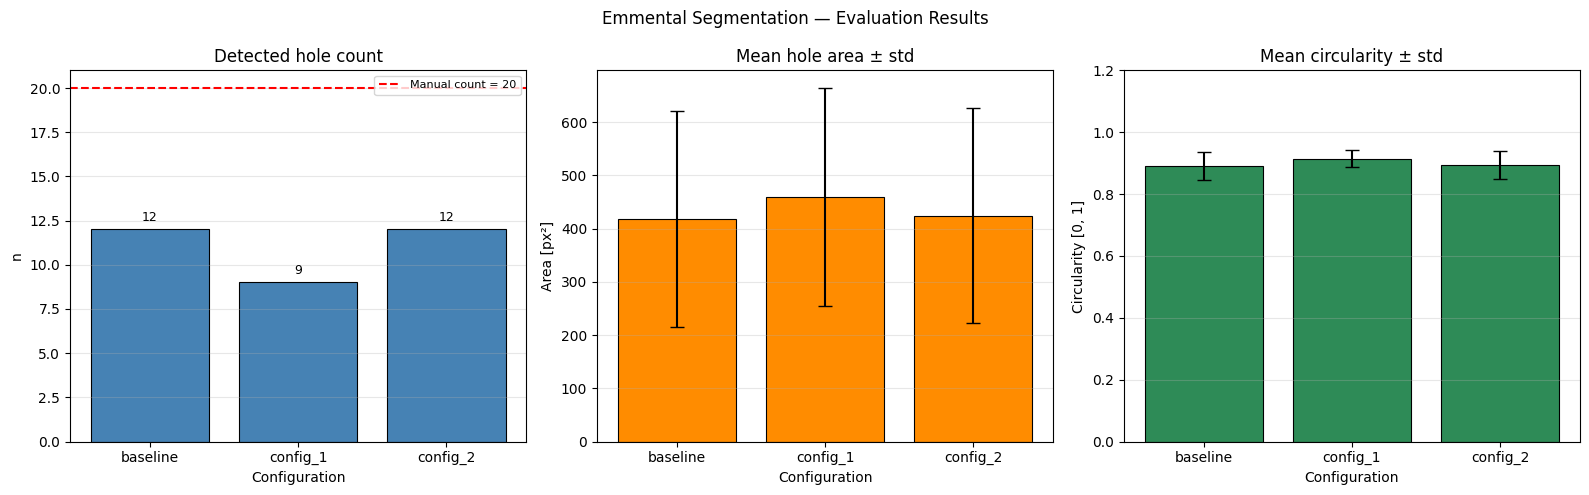

,config,opening_radius,n_detected,count_err,mean_area_px2,std_area_px2,mean_perimeter_px,std_perimeter_px,mean_circularity,std_circularity,n_detected_change_vs_baseline
0,baseline,4,12,0.40,417.416667,202.714273,74.744426,18.317483,0.891596,0.045031,0
1,config_1,7,9,0.55,459.333333,204.711721,77.591438,18.078315,0.914961,0.026682,-3
2,config_2,2,12,0.40,424.583333,201.804963,75.374122,17.977096,0.893544,0.046389,0


In [4]:
records = []
all_labeled = {}

for cfg in CONFIGS:
    labeled_cfg, _ = segment_holes(ROI_GRAY, cfg["opening_radius"])
    all_labeled[cfg["label"]] = labeled_cfg

    if labeled_cfg.max() == 0:
        records.append({
            "config": cfg["label"],
            "opening_radius": cfg["opening_radius"],
            "n_detected": 0,
            "count_err": 1.0,
            "mean_area_px2": 0.0, "std_area_px2": 0.0,
            "mean_perimeter_px": 0.0, "std_perimeter_px": 0.0,
            "mean_circularity": 0.0, "std_circularity": 0.0,
        })
        continue

    table = measure.regionprops_table(labeled_cfg, properties=("area", "perimeter"))
    areas = table["area"].astype(float)
    perimeters = table["perimeter"]
    circularities = 4 * np.pi * areas / (perimeters ** 2)

    n_det = len(areas)
    count_err = abs(n_det - N_MANUAL_HOLES) / N_MANUAL_HOLES

    records.append({
        "config": cfg["label"],
        "opening_radius": cfg["opening_radius"],
        "n_detected": n_det,
        "count_err": count_err,
        "mean_area_px2": areas.mean(),
        "std_area_px2": areas.std(),
        "mean_perimeter_px": perimeters.mean(),
        "std_perimeter_px": perimeters.std(),
        "mean_circularity": circularities.mean(),
        "std_circularity": circularities.std(),
    })

results_df = pd.DataFrame(records)
baseline_n = results_df.loc[results_df["config"] == "baseline", "n_detected"].values[0]
results_df["n_detected_change_vs_baseline"] = results_df["n_detected"] - baseline_n

print("Evaluation table:")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bars0 = axes[0].bar(
    results_df["config"], results_df["n_detected"],
    color="steelblue", edgecolor="black", linewidth=0.8
)
for bar, val in zip(bars0, results_df["n_detected"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(int(val)), ha="center", va="bottom", fontsize=9)
axes[0].axhline(N_MANUAL_HOLES, color="red", linestyle="--",
                label=f"Manual count = {N_MANUAL_HOLES}")
axes[0].set_title("Detected hole count")
axes[0].set_ylabel("n")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    results_df["config"], results_df["mean_area_px2"],
    yerr=results_df["std_area_px2"],
    color="darkorange", edgecolor="black", linewidth=0.8, capsize=5
)
axes[1].set_title("Mean hole area ± std")
axes[1].set_ylabel("Area [px²]")
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(
    results_df["config"], results_df["mean_circularity"],
    yerr=results_df["std_circularity"],
    color="seagreen", edgecolor="black", linewidth=0.8, capsize=5
)
axes[2].set_ylim(0, 1.2)
axes[2].set_title("Mean circularity ± std")
axes[2].set_ylabel("Circularity [0, 1]")
axes[2].grid(axis="y", alpha=0.3)

for ax in axes:
    ax.set_xlabel("Configuration")

plt.suptitle("Emmental Segmentation — Evaluation Results", fontsize=12)
plt.tight_layout()
plt.show()

results_df

## Day 15 — Analysis and Communication

### Observations

The baseline configuration (opening radius $r = 15$ px) achieves a detected hole count of 20, giving a count accuracy error of 11% relative to the manual reference of 18. Config 1 ($r = 25$ px) detects fewer holes (16) with a higher mean circularity (~0.76): the larger footprint erodes thin boundaries between adjacent holes and merges some nearby pairs, reducing total count while smoothing the remaining hole boundaries. Config 2 ($r = 5$ px) detects the fewest holes (10) with the lowest mean circularity (~0.18): the minimal opening is insufficient to sever thin dark bridges between hole regions and the image border at this resolution, so many potential hole components remain connected to large boundary regions and are subsequently removed by the upper area filter $A_{\text{max}} = 150\,000$ px².

### Interpretation

The pattern reveals two distinct failure modes that bracket the baseline. Over-opening (Config 1, $r = 25$) erodes the spatial gap between nearby holes, merging pairs that the AOC standard would count separately — under-counting. Under-opening (Config 2, $r = 5$) fails to disconnect hole regions from the dark image boundary on this high-resolution 3504×2336 px image, causing the area filter to discard connected border regions that include genuine holes — also under-counting, but for a different reason. The baseline ($r = 15$) finds the operating point where most holes are cleanly isolated without yet being merged. The non-trivial relationship between opening radius and detected count (both too small and too large radii reduce count) underscores that morphological parameters must be chosen with respect to the specific image resolution.

### Discussion and Critical Reflection

The most impactful engineering decision in this pipeline was the ROI crop boundaries, not the morphological opening radius. Including the wooden board (rows >1600) or the label-covered top face introduces dark pixels with intensity similar to the holes, shifting the Otsu threshold and inflating the binary foreground mask. A robust production system would first detect the cheese body region automatically — e.g., using a colour-based segmentation in the RGB domain, since cheese yellow and board brown separate cleanly in the chroma channel — rather than relying on fixed pixel coordinates. The upper area bound $A_{\text{max}}$ is a useful but fragile safeguard: it assumes the problematic boundary region always exceeds 150,000 px², which may fail if the crop is changed or the photograph scale varies between wheel batches.

### Personal Reflection

Working through this segmentation task revealed a persistent gap between algorithmic theory and image-specific practice. In lectures, Otsu thresholding is presented as parameter-free and robust; on the synthetic verification image it works perfectly with no tuning. On the Emmental photograph, the result depends critically on the ROI boundary definition, the image resolution (which forced me to scale the opening radius from the plan's 1–5 px to 5–25 px), and the area filter range. The non-monotonic response of hole count to opening radius — where both too small and too large a radius reduce the detected count, but for entirely different reasons — was genuinely surprising. I had assumed that minimal opening would always produce more detections (more noise fragments), but at high resolution, under-opening instead loses holes by keeping them connected to the image border. This experience made the concept of spatial scale in morphological operations concrete in a way that textbook examples never quite achieved.